In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
from torch import nn
from torch.nn import functional as F
import copy

import sys
import os
import pathlib
import pickle
import itertools
from typing import Callable

from omegaconf import OmegaConf

import tqdm.notebook as tqdm

In [2]:
sys.path.append(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src')

import data_preparation
import models_gnn
import model_loader
import losses
import run_experiment

In [3]:
device = torch.device('cpu')

if torch.cuda.is_available():
    device = torch.device('cuda')

device

device(type='cuda')

In [4]:
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\sym_no_reg\pos_init\dump_pos_init_seed_269_adj_269.bin')
# path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\sym_no_reg\neighbors_init\dump_neighbors_init_seed_269_adj_269.bin')
print(f"{path=}")

with open(path, 'rb') as f:
    target_run_info = pickle.load(f)

path=WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps/sym_no_reg/pos_init/dump_pos_init_seed_269_adj_269.bin')


In [5]:
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\sym_no_reg\random_init\dump_random_init_seed_269_adj_4615.bin')
# path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\sym_no_reg\pos_init\dump_pos_init_seed_269_adj_269.bin')
print(f"{path=}")

with open(path, 'rb') as f:
    random_run_info = pickle.load(f)

path=WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps/sym_no_reg/random_init/dump_random_init_seed_269_adj_4615.bin')


<Axes: >

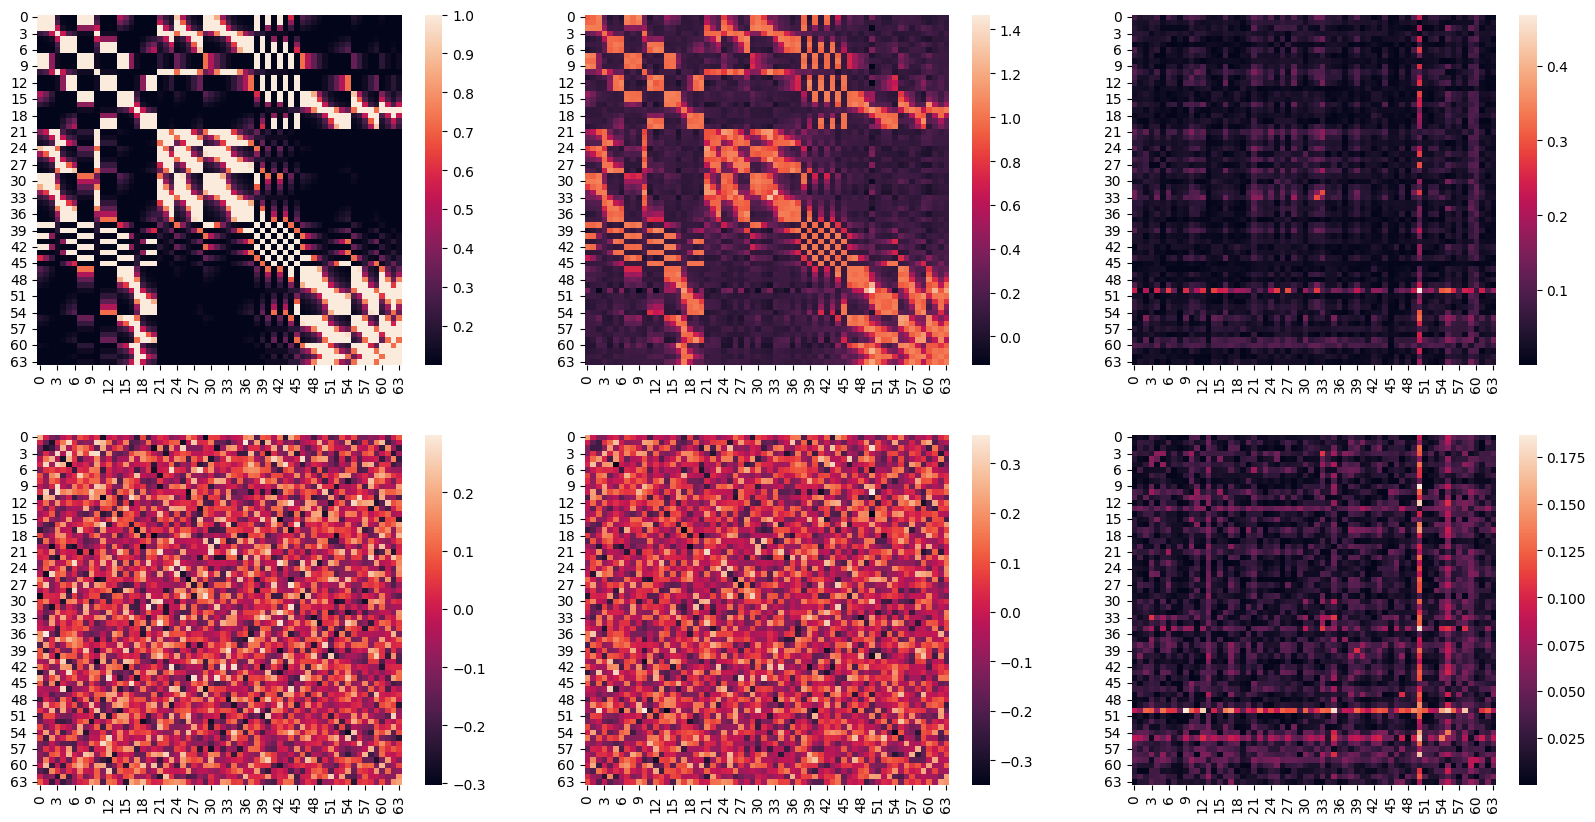

In [6]:
_, ax = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))

adj_init = target_run_info['adj']['init']
adj_final = target_run_info['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[0, 0])
sns.heatmap(adj_final, ax=ax[0, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[0, 2])


adj_init = random_run_info['adj']['init']
adj_final = random_run_info['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[1, 0])
sns.heatmap(adj_final, ax=ax[1, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[1, 2])

In [7]:
def adj_conv(adj_1: torch.Tensor, adj_2: torch.Tensor) -> Callable:
    def conv(theta: float) -> torch.Tensor:
        return adj_2 * theta + adj_1 * (1.0 -  theta)
    
    return conv

In [8]:
def get_nn(base_nn, adj_matrix, cfg):
    if isinstance(adj_matrix, np.ndarray):
        adj_matrix = torch.from_numpy(adj_matrix)

    adj_layer = models_gnn.AdjLayer(
        n_channels=cfg.n_channels, 
        init_mat=adj_matrix,
        is_sym=cfg.adj_sym
    )

    base_nn.gc.adj = adj_layer

    return base_nn

In [9]:
@torch.inference_mode
def score_model(model: nn.Module, dataloader: torch.utils.data.DataLoader, criterion: losses.HybridLoss):
    model.eval()
    running_TP, running_TN, running_FP, running_FN = 0, 0, 0, 0
    running_loss = 0.0
    num_objs = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        inputs_size = inputs.size(0)

        outputs = model(inputs)
        loss = criterion(input=outputs, target=labels, adj=model.gc.adj.adj_mat)

        _, preds = torch.max(outputs, 1)
        _, true_y = torch.max(labels.data, 1)

        P = torch.sum(preds)
        N = torch.sum(1 - preds)
        TP = torch.sum(torch.masked_select(true_y, preds == 1))
        TN = torch.sum(torch.masked_select(1 - true_y, preds == 0))
        FP = P - TP
        FN = N - TN

        running_loss += loss.item() * inputs_size
        running_TP += TP.item()
        running_TN += TN.item()
        running_FP += FP.item()
        running_FN += FN.item()
        num_objs += inputs_size

    running_loss = running_loss / num_objs

    return {
        'loss': running_loss,
        'TP': running_TP,
        'TN': running_TN,
        'FP': running_FP,
        'FN': running_FN,
    }

In [10]:
def calc_accuracy(TP: int, TN: int, FP: int, FN: int, **kwargs):
    return (TP + TN) / (TP + TN + FP + FN)

def calc_recall(TP: int, TN: int, FP: int, FN: int, **kwargs):
    return TP / (TP + FN)

def calc_precision(TP: int, TN: int, FP: int, FN: int, **kwargs):
    return TP / (TP + FP)

def calc_f1(TP: int, TN: int, FP: int, FN: int, **kwargs):
    precision = calc_precision(TP=TP, TN=TN, FP=FP, FN=FN)
    recall = calc_recall(TP=TP, TN=TN, FP=FP, FN=FN)

    f1 = 2 * precision * recall / (precision + recall)

    return f1

# Замороженные веса

In [ ]:
cfg_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\configs\viewer_cfg.yaml'
cfg = OmegaConf.load(cfg_path) 

train_dataset, test_dataset = data_preparation.load_dataset(cfg)
_, test_dataloader = data_preparation.get_dataloaders(cfg, train_dataset, test_dataset)

criterion = model_loader.load_criterion(cfg)

In [ ]:
train_res = run_experiment.run(cfg_path)

In [ ]:
base_nn = copy.deepcopy(train_res['model'])

base_nn

In [ ]:
# base_nn = get_nn(base_nn, adj_matrix=random_run_info['adj']['init'])
# base_nn = get_nn(base_nn, adj_matrix=target_run_info['adj']['init'])

# base_nn.gc.adj.adj_mat

In [ ]:
mid_model = get_nn(base_nn, adj_matrix=random_run_info['adj']['final']).to(device)
scores = score_model(mid_model, test_dataloader, criterion)

f1 = calc_f1(**scores)
accuracy = calc_accuracy(**scores)

print(scores)
print(f"{f1=}\t{accuracy=}")

In [ ]:
mid_model = get_nn(base_nn, adj_matrix=target_run_info['adj']['final']).to(device)
scores = score_model(mid_model, test_dataloader, criterion)

f1 = calc_f1(**scores)
accuracy = calc_accuracy(**scores)

print(scores)
print(f"{f1=}\t{accuracy=}")

In [ ]:
adj_geodetic = adj_conv(
    # adj_1=random_run_info['adj']['final'],
    adj_1=train_res['logs']['adj']['final'],
    adj_2=target_run_info['adj']['final']
)
criterion = model_loader.load_criterion(cfg)

thetas = np.linspace(0.0, 1.0, num=500)

f1_ls = np.zeros_like(thetas)
acc_ls = np.zeros_like(thetas)
loss_ls = np.zeros_like(thetas)

for i, theta in enumerate(thetas):
    adj_mat = adj_geodetic(theta)
    mid_model = get_nn(base_nn, adj_matrix=adj_mat).to(device)

    scores = score_model(mid_model, test_dataloader, criterion)
    f1 = calc_f1(**scores)
    accuracy = calc_accuracy(**scores)

    f1_ls[i] = f1
    acc_ls[i] = accuracy
    loss_ls[i] = scores['loss']

In [ ]:
_, ax = plt.subplots(ncols=3, figsize=(20, 6))

ax[0].plot(thetas, f1_ls)
ax[0].set_xlabel('Theta')
ax[0].set_ylabel('F1-score')

ax[1].plot(thetas, acc_ls)
ax[1].set_xlabel('Theta')
ax[1].set_ylabel('Accuracy')

ax[2].plot(thetas, loss_ls)
ax[2].set_xlabel('Theta')
ax[2].set_ylabel('Loss')

In [ ]:
_, ax = plt.subplots(ncols=3, figsize=(20, 6))

ax[0].plot(thetas, f1_ls)
ax[0].set_xlabel('Theta')
ax[0].set_ylabel('F1-score')

ax[1].plot(thetas, acc_ls)
ax[1].set_xlabel('Theta')
ax[1].set_ylabel('Accuracy')

ax[2].plot(thetas, loss_ls)
ax[2].set_xlabel('Theta')
ax[2].set_ylabel('Loss')

# Обучение с различными инициализациями

In [11]:
def run_sample(theta: float, adj_geodetic):
    cfg_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\configs\viewer_ft_cfg.yaml'
    work_cfg_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\configs\viewer_ft_working.yaml'
    init_dump_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\viewer_adj_init.bin'

    # uploading config
    cfg = OmegaConf.load(cfg_path)
    cfg['run_name'] = f'viewer_random_pos_{theta=:.4f}'.replace('.', '')
    cfg['adj_init'] = init_dump_path

    with open(work_cfg_path, 'w') as f:
        print(
            OmegaConf.to_yaml(cfg, resolve=True),
            file=f
        )
    
    # uploading adj_init
    adj = adj_geodetic(theta)
    if isinstance(adj, np.ndarray):
        adj = torch.from_numpy(adj)
    with open(init_dump_path, 'wb') as f:
        pickle.dump(
            obj=adj,
            file=f
        )

    train_res = run_experiment.run(work_cfg_path)

    return train_res

In [12]:
train_res_ls = []

thetas = np.linspace(0.0, 1.0, num=41)
adj_geodetic = adj_conv(
    adj_1=random_run_info['adj']['init'],
    adj_2=target_run_info['adj']['init']
)

for i, theta in tqdm.tqdm(enumerate(thetas), total=len(thetas)):
    train_res = run_sample(theta, adj_geodetic)
    train_res_ls.append(train_res)

  0%|          | 0/41 [00:00<?, ?it/s]

tensor([42,  0,  0,  ...,  0,  0,  0], dtype=torch.uint8)


C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformati


100%|██████████| 200/200 [05:18<00:00,  1.59s/it]


train/FN,██▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▁▁▂▁▁▁
train/FP,█▄▃▃▃▂▃▂▂▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/TN,▁▃▄▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██▇██████████████
train/TP,▁▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██▇▇███████████
train/epoch_acc,▁▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████████
train/epoch_bc,▁▄▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇█████████
train/epoch_f1,▁▄▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████████████████████
train/epoch_ones,█▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▂▂▂▁▂▁▂▁▂▁▂▂▁▁▁▁▁▂▁▁
train/epoch_precision,▁▃▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████
train/epoch_recall,▂▁▁▁▂▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▆▆▇▇▇▇▇█▇▇▇█▇█▇█
train/loss,█▆▅▅▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁


...

train_stats=defaultdict(<function train_model.<locals>.<lambda> at 0x000001D1E3AEA980>, {'TP': [7429, 7867, 8439, 8293, 8046, 7804, 7853, 7750, 7693, 7804, 7797, 7683, 7708, 7798, 7875, 7842, 7827, 7899, 7914, 7870, 7937, 7765, 7917, 7937, 8000, 8021, 7891, 7931, 7971, 7974, 7937, 7951, 7943, 7985, 8075, 8083, 8065, 8079, 7980, 8048, 7942, 7968, 8023, 8027, 8040, 8127, 8115, 8090, 8176, 8164, 8180, 8219, 8146, 8095, 8117, 8260, 8148, 8192, 8229, 8265, 8351, 8275, 8277, 8298, 8292, 8259, 8234, 8146, 8227, 8314, 8263, 8230, 8212, 8166, 8206, 8202, 8179, 8204, 8206, 8176, 8172, 8206, 8086, 8254, 8256, 8249, 8239, 8266, 8249, 8314, 8180, 8255, 8228, 8262, 8274, 8196, 8245, 8244, 8321, 8355, 8252, 8354, 8349, 8227, 8303, 8228, 8378, 8382, 8389, 8355, 8318, 8400, 8526, 8387, 8473, 8492, 8402, 8450, 8455, 8352, 8309, 8393, 8280, 8385, 8379, 8368, 8481, 8302, 8505, 8502, 8418, 8403, 8437, 8443, 8441, 8366, 8406, 8457, 8399, 8473, 8412, 8368, 8485, 8559, 8477, 8581, 8499, 8459, 8438, 8543, 8407


  0%|          | 0/85 [00:00<?, ?it/s]C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)

  4%|▎         | 3/85 [00:00<00:02, 29.33it/s]C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWa


100%|██████████| 200/200 [05:26<00:00,  1.63s/it]


train/FN,▆▇█▇▇▆▆▆▆▅▄▄▅▅▆▅▅▄▃▃▃▃▄▃▂▂▃▂▃▂▃▃▂▃▂▃▂▁▁▂
train/FP,██▇▆▆▅▅▅▄▄▃▂▂▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▂▁▂▂▂
train/TN,▂▁▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███▇██████████
train/TP,▁▇▃▂▃▃▄▄▄▄▃▄▄▅▅▆▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███▇▇█▇██
train/epoch_acc,▁▃▃▃▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train/epoch_bc,▁▂▂▂▃▃▄▄▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█████████
train/epoch_f1,▁▂▃▂▃▃▃▃▃▄▄▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▆▇▇▇▇▇▇█▇████
train/epoch_ones,█▄▃▃▄▃▃▃▃▃▃▂▂▃▂▂▂▂▂▁▂▂▁▁▂▁▁▂▁▂▁▂▂▁▁▂▂▂▂▂
train/epoch_precision,▁▂▃▃▃▄▄▄▄▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
train/epoch_recall,▅▂▁▂▂▃▃▃▃▄▄▅▄▄▅▄▅▅▅▄▄▅▅▄▄▆▆▆▅▆▇▇█▇▆▇▇▇██
train/loss,███▇▇▇▇▆▆▆▆▆▅▅▅▄▄▄▄▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁


train_stats=defaultdict(<function train_model.<locals>.<lambda> at 0x000001D1E3AE9F80>, {'TP': [7437, 7863, 8431, 8259, 8029, 7793, 7832, 7731, 7677, 7817, 7817, 7689, 7700, 7784, 7868, 7833, 7805, 7896, 7923, 7860, 7963, 7746, 7911, 7945, 8002, 8023, 7893, 7937, 7990, 8023, 7995, 7998, 7974, 7946, 7999, 8028, 8030, 8074, 8050, 7990, 7876, 7981, 8058, 8018, 8036, 8095, 8132, 8118, 8141, 8117, 8171, 8232, 8147, 8108, 8139, 8243, 8163, 8198, 8195, 8167, 8352, 8328, 8272, 8268, 8255, 8250, 8205, 8235, 8181, 8231, 8167, 8152, 8128, 8028, 8190, 8204, 8143, 8214, 8274, 8253, 8264, 8156, 8154, 8282, 8286, 8213, 8207, 8313, 8258, 8297, 8362, 8245, 8132, 8234, 8284, 8186, 8289, 8266, 8303, 8360, 8201, 8309, 8295, 8199, 8342, 8232, 8363, 8398, 8360, 8383, 8362, 8411, 8448, 8336, 8575, 8521, 8411, 8406, 8535, 8323, 8454, 8569, 8337, 8462, 8440, 8447, 8492, 8319, 8484, 8501, 8418, 8462, 8484, 8533, 8502, 8487, 8392, 8471, 8516, 8619, 8476, 8498, 8482, 8684, 8519, 8631, 8606, 8531, 8471, 8597, 8393

In [13]:
train_res_ls[0]['logs']['train_curve']['validation'].keys()

dict_keys(['TP', 'TN', 'FP', 'FN', 'accuracy', 'f1', 'loss'])

In [ ]:
# with open(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\viewer_curves\pos_to_random.bin', 'wb') as f:
#     pickle.dump(train_res_ls, file=f)

In [14]:
thetas = np.linspace(0.0, 1.0, num=41)

with open(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\viewer_curves\pos_to_random.bin', 'rb') as f:
    train_res_ls = pickle.load(f)

In [15]:
best_step_idxs = []
best_f1 = []
best_acc = []
best_loss = []

for train_res in train_res_ls:
    f1_scores = train_res['logs']['train_curve']['validation']['f1']
    acc_scores = train_res['logs']['train_curve']['validation']['accuracy']
    loss = train_res['logs']['train_curve']['validation']['loss']
    best_idx = np.argmax(f1_scores)

    best_step_idxs.append(best_idx)
    best_f1.append(f1_scores[best_idx])
    best_acc.append(acc_scores[best_idx])
    best_loss.append(loss[best_idx])

best_step_idxs = np.array(best_step_idxs)
best_f1 = np.array(best_f1)
best_acc = np.array(best_acc)

Text(0, 0.5, 'Loss')

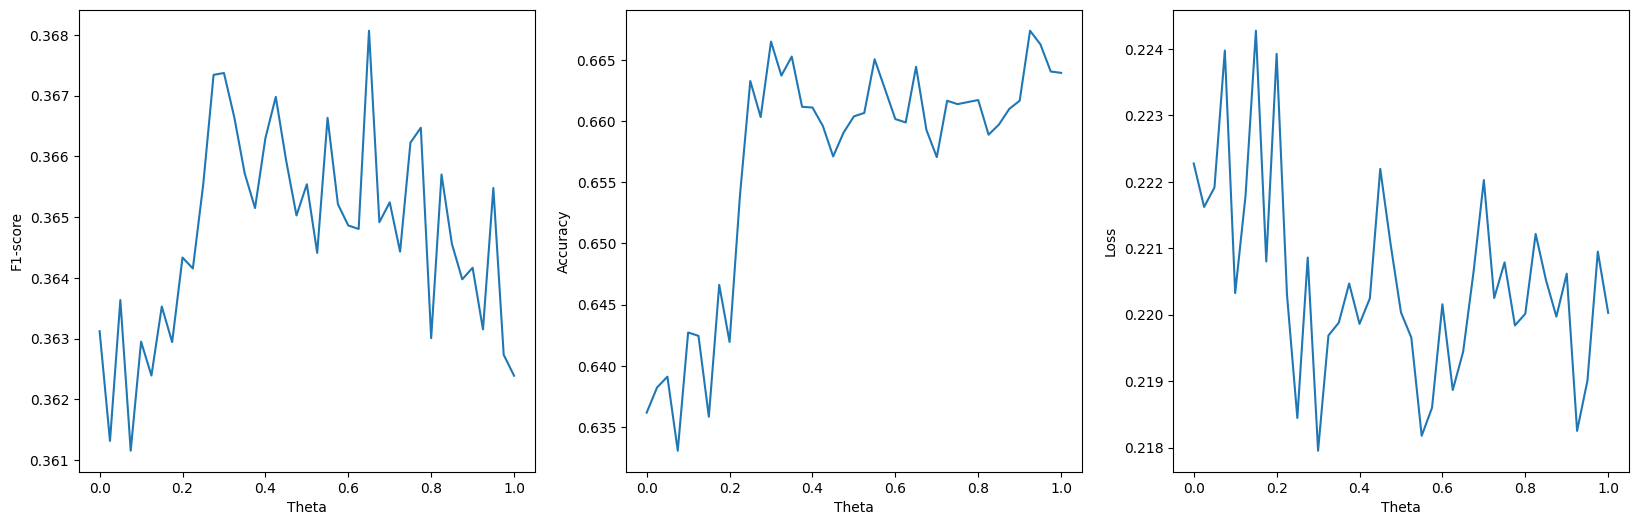

In [16]:
_, ax = plt.subplots(ncols=3, figsize=(20, 6))

ax[0].plot(thetas, best_f1)
ax[0].set_xlabel('Theta')
ax[0].set_ylabel('F1-score')

ax[1].plot(thetas, best_acc)
ax[1].set_xlabel('Theta')
ax[1].set_ylabel('Accuracy')

ax[2].plot(thetas, best_loss)
ax[2].set_xlabel('Theta')
ax[2].set_ylabel('Loss')

In [17]:
idx = np.argmin(best_acc)

print(f"Worst results: F1={best_f1[idx]:.4f}\tAcc={best_acc[idx]:.4f}\tLoss={best_loss[idx]:.4f}")

Worst results: F1=0.3147	Acc=0.5862	Loss=0.2378


<Axes: >

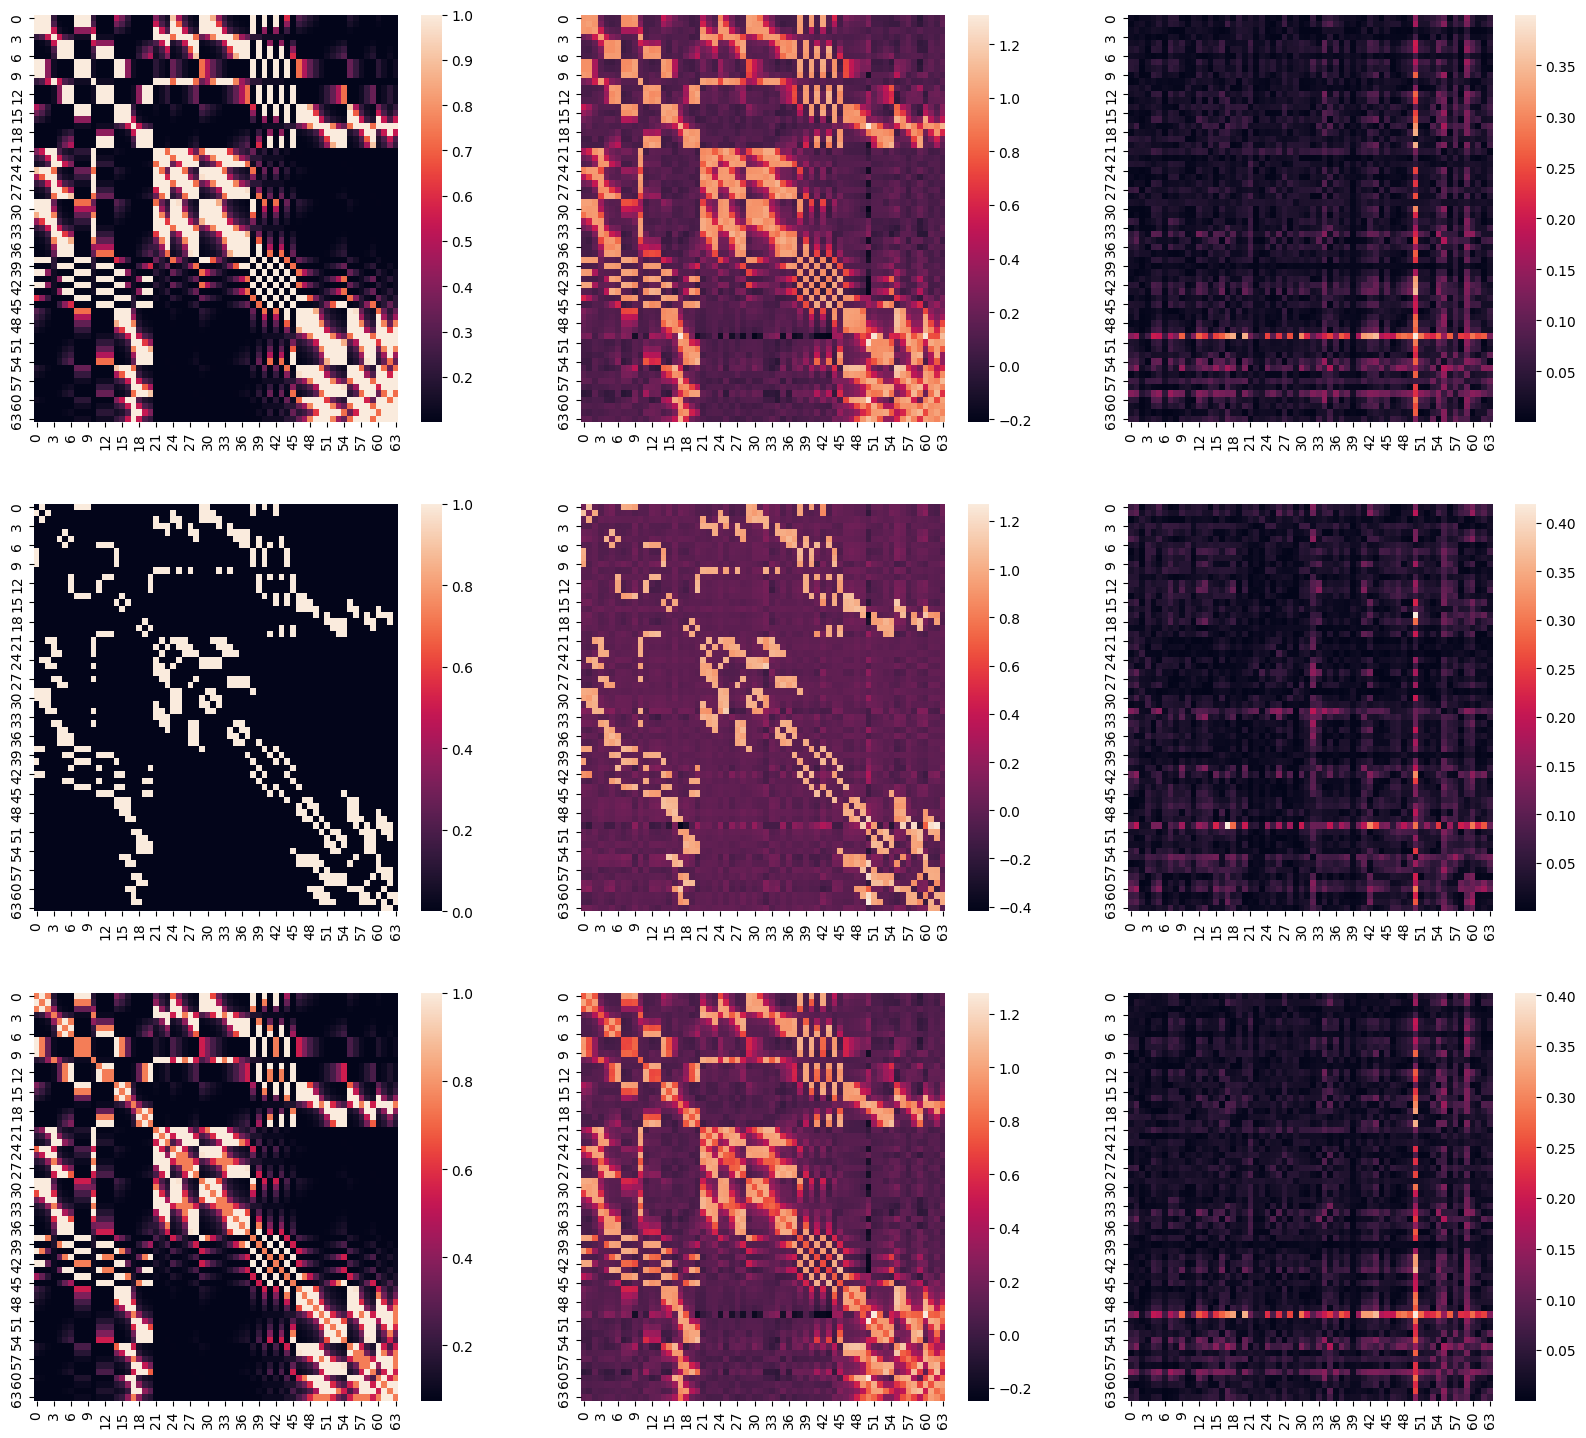

In [18]:
_, ax = plt.subplots(ncols=3, nrows=3, figsize=(20, 18))

adj_init = train_res_ls[0]['logs']['adj']['init']
adj_final = train_res_ls[0]['logs']['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[0, 0])
sns.heatmap(adj_final, ax=ax[0, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[0, 2])


adj_init = train_res_ls[-1]['logs']['adj']['init']
adj_final = train_res_ls[-1]['logs']['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[1, 0])
sns.heatmap(adj_final, ax=ax[1, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[1, 2])

delta = -idx + 10
adj_init = train_res_ls[idx + delta]['logs']['adj']['init']
adj_final = train_res_ls[idx + delta]['logs']['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[2, 0])
sns.heatmap(adj_final, ax=ax[2, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[2, 2])

In [19]:
cfg_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\configs\viewer_ft_cfg.yaml'
cfg = OmegaConf.load(cfg_path) 

train_dataset, test_dataset = data_preparation.load_dataset(cfg)
train_dataloader, test_dataloader = data_preparation.get_dataloaders(cfg, train_dataset, test_dataset)

criterion = model_loader.load_criterion(cfg)

  0%|          | 0/85 [00:00<?, ?it/s]C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
  5%|▍         | 4/85 [00:00<00:02, 34.60it/s]C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarn

KeyboardInterrupt: 

In [111]:
adj_masked = copy.deepcopy(train_res_ls[0]['logs']['adj']['final'])

masked_nn = copy.deepcopy(train_res_ls[0]['model'])
masked_nn = get_nn(masked_nn, adj_matrix=adj_masked, cfg=cfg).to(device)

raw_scores = {
    'validation': score_model(masked_nn, test_dataloader, criterion),
    'train': score_model(masked_nn, train_dataloader, criterion)
}

print("Validation:")
print(f"\tLoss={raw_scores['validation']['loss']:.4f}\tAccuracy={calc_accuracy(**raw_scores['validation']):.4f}\tF1-score={calc_f1(**raw_scores['validation']):.4f}")

print("Train:")
print(f"\tLoss={raw_scores['train']['loss']:.4f}\tAccuracy={calc_accuracy(**raw_scores['train']):.4f}\tF1-score={calc_f1(**raw_scores['train']):.4f}")

Validation:
	Loss=0.2204	Accuracy=0.6496	F1-score=0.3545
Train:
	Loss=0.2011	Accuracy=0.6968	F1-score=0.6995


In [84]:
mask = np.zeros_like(adj_final, dtype=bool)
mask[50, :] = True
mask[:, 50] = True

adj_masked = np.where(
    mask,
    train_res_ls[0]['logs']['adj']['final'],
    0.0
)

masked_nn = copy.deepcopy(train_res_ls[0]['model'])
masked_nn = get_nn(masked_nn, adj_matrix=adj_masked, cfg=cfg).to(device)

scores = score_model(masked_nn, test_dataloader, criterion)

print(f"Loss={scores['loss']:.4f}\tAccuracy={calc_accuracy(**scores):.4f}\tF1-score={calc_f1(**scores):.4f}")

Loss=0.2491	Accuracy=0.6168	F1-score=0.2728


In [85]:
mask = np.ones_like(adj_final, dtype=bool)
mask[50, :] = False
mask[:, 50] = False

adj_masked = np.where(
    mask,
    train_res_ls[0]['logs']['adj']['final'],
    0.0
)

masked_nn = copy.deepcopy(train_res_ls[0]['model'])
masked_nn = get_nn(masked_nn, adj_matrix=adj_masked, cfg=cfg).to(device)

scores = score_model(masked_nn, test_dataloader, criterion)

print(f"Loss={scores['loss']:.4f}\tAccuracy={calc_accuracy(**scores):.4f}\tF1-score={calc_f1(**scores):.4f}")

Loss=0.2432	Accuracy=0.6228	F1-score=0.2913


In [127]:
masked_f1 = {
    'validation': np.zeros_like(adj_final),
    'train': np.zeros_like(adj_final),
}
masked_acc = {
    'validation': np.zeros_like(adj_final),
    'train': np.zeros_like(adj_final),
}
masked_loss = {
    'validation': np.zeros_like(adj_final),
    'train': np.zeros_like(adj_final),
}

masked_nn = copy.deepcopy(train_res_ls[0]['model'])

for i in tqdm.tqdm(range(64)):
    for j in range(i, 64):
        mask = np.ones_like(adj_final, dtype=bool)
        mask[i, j] = False
        mask[j, i] = False

        adj_masked = np.where(
            mask,
            train_res_ls[0]['logs']['adj']['final'],
            0.0
        )

        masked_nn = get_nn(masked_nn, adj_matrix=adj_masked, cfg=cfg).to(device)

        for ds_split, dataloader in zip(
            ('train', 'validation'),
            (train_dataloader, test_dataloader),
            ):
            
            scores = score_model(masked_nn, dataloader, criterion)

            masked_f1[ds_split][i, j] = calc_f1(**scores)
            masked_acc[ds_split][i, j] = calc_accuracy(**scores)
            masked_loss[ds_split][i, j] = scores['loss']

            masked_f1[ds_split][j, i] = masked_f1[ds_split][i, j]
            masked_acc[ds_split][j, i] = masked_acc[ds_split][i, j]
            masked_loss[ds_split][j, i] = masked_loss[ds_split][i, j]

  0%|          | 0/64 [00:00<?, ?it/s]

In [ ]:
# with open(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\viewer\masked_scores_sym.bin', 'wb') as f:
#     pickle.dump(
#         obj=(masked_f1, masked_acc, masked_loss, raw_scores),
#         file=f
#     )

Text(0.5, 1.0, 'Loss')

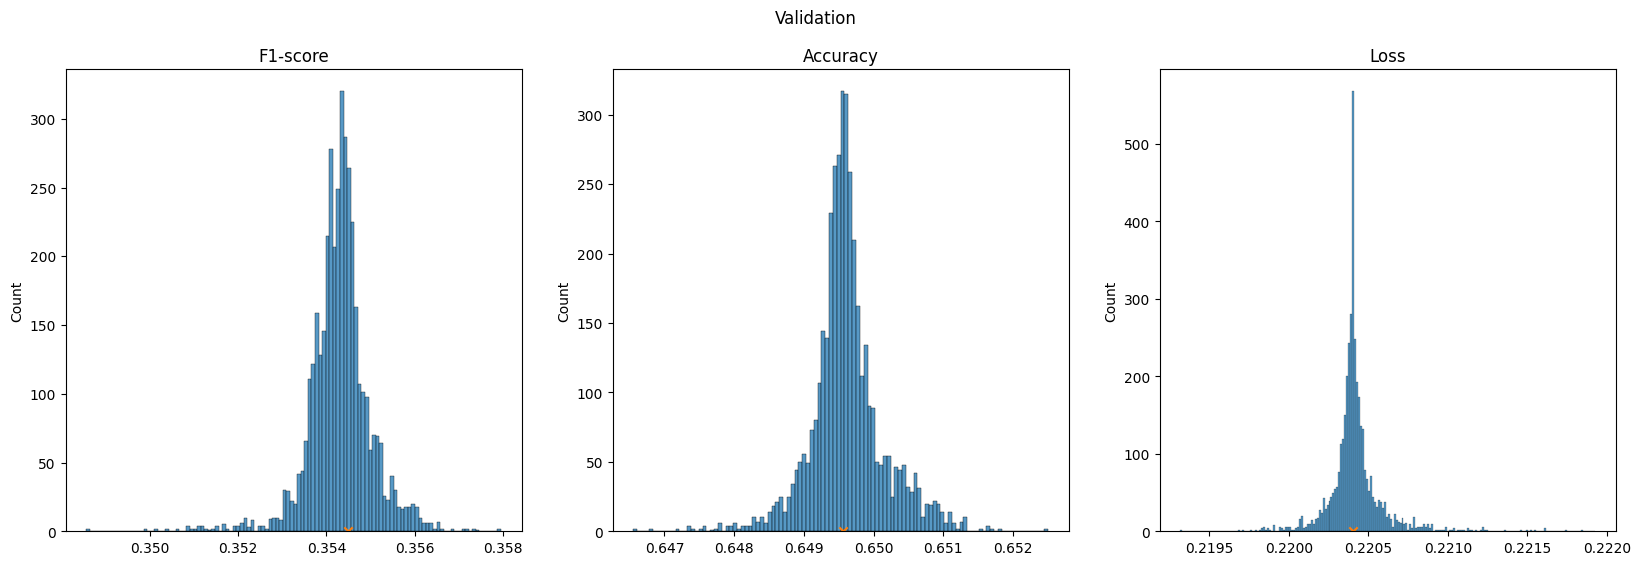

In [129]:
fig, ax = plt.subplots(ncols=3, figsize=(20, 6))
fig.suptitle('Validation')

sns.histplot(
    masked_f1['validation'].ravel(),
    ax=ax[0]
)
ax[0].scatter([calc_f1(**raw_scores['validation'])], [0], marker='x')
ax[0].set_title('F1-score')


sns.histplot(
    masked_acc['validation'].ravel(),
    ax=ax[1]
)
ax[1].scatter([calc_accuracy(**raw_scores['validation'])], [0], marker='x')
ax[1].set_title('Accuracy')


sns.histplot(
    masked_loss['validation'].ravel(),
    ax=ax[2]
)
ax[2].scatter([raw_scores['validation']['loss']], [0], marker='x')
ax[2].set_title('Loss')

Text(0.5, 1.0, 'Loss')

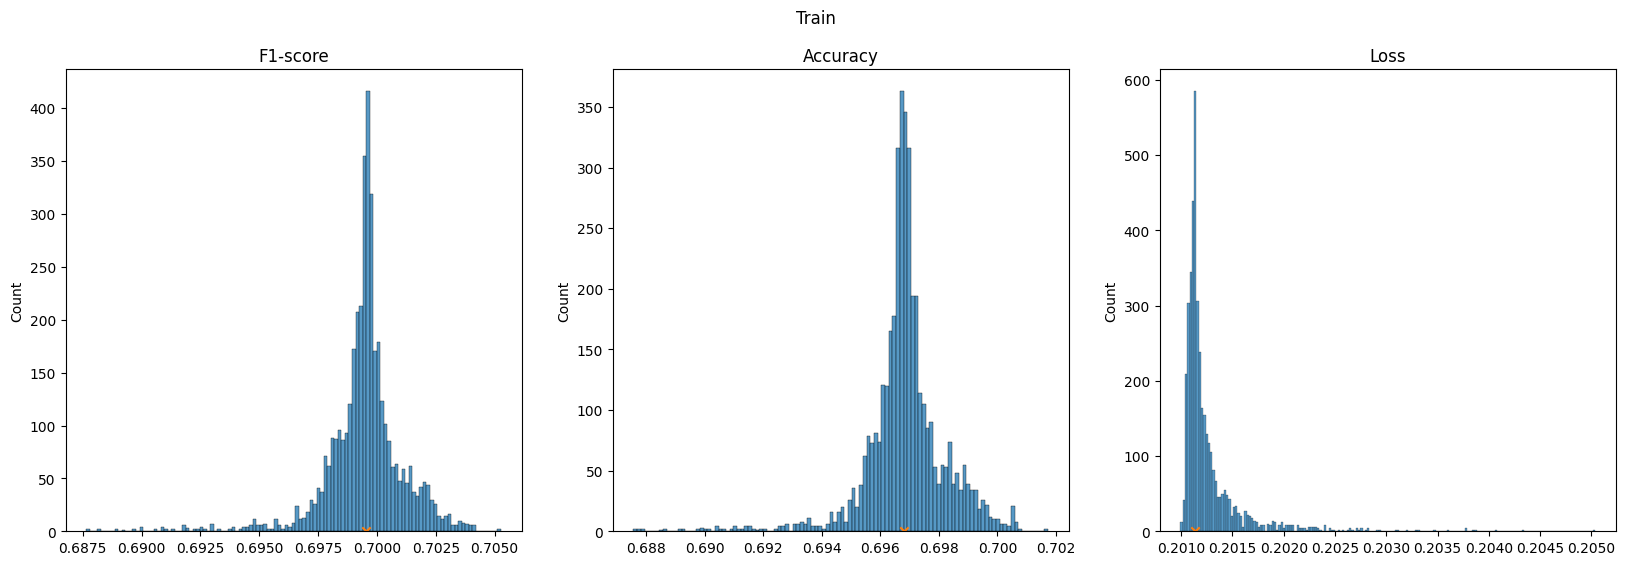

In [130]:
fig, ax = plt.subplots(ncols=3, figsize=(20, 6))
fig.suptitle('Train')

sns.histplot(
    masked_f1['train'].ravel(),
    ax=ax[0]
)
ax[0].scatter([calc_f1(**raw_scores['train'])], [0], marker='x')
ax[0].set_title('F1-score')


sns.histplot(
    masked_acc['train'].ravel(),
    ax=ax[1]
)
ax[1].scatter([calc_accuracy(**raw_scores['train'])], [0], marker='x')
ax[1].set_title('Accuracy')


sns.histplot(
    masked_loss['train'].ravel(),
    ax=ax[2]
)
ax[2].scatter([raw_scores['train']['loss']], [0], marker='x')
ax[2].set_title('Loss')

Text(0.5, 1.0, 'Train, neg-loss')

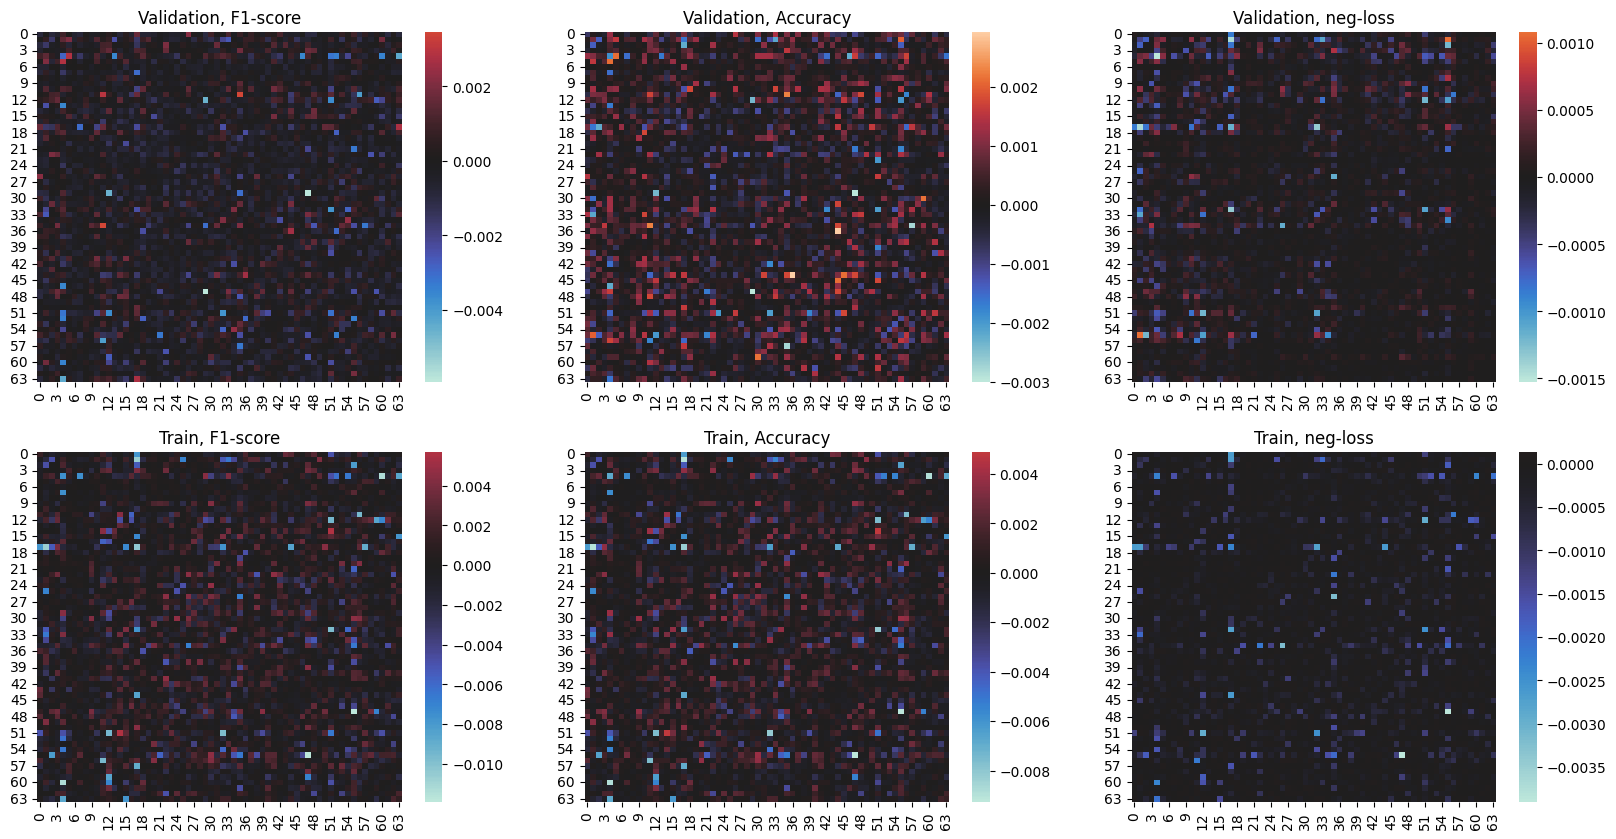

In [131]:
_, ax = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))

# Validation
sns.heatmap(
    masked_f1['validation'] - calc_f1(**raw_scores['validation']),
    center=0,
    ax=ax[0, 0]
)
ax[0, 0].set_title('Validation, F1-score')

sns.heatmap(
    masked_acc['validation'] - calc_accuracy(**raw_scores['validation']),
    center=0,
    ax=ax[0, 1]
)
ax[0, 1].set_title('Validation, Accuracy')

sns.heatmap(
    -(masked_loss['validation'] - raw_scores['validation']['loss']),
    center=0,
    ax=ax[0, 2]
)
ax[0, 2].set_title('Validation, neg-loss')


# Train
sns.heatmap(
    masked_f1['train'] - calc_f1(**raw_scores['train']),
    center=0,
    ax=ax[1, 0]
)
ax[1, 0].set_title('Train, F1-score')

sns.heatmap(
    masked_acc['train'] - calc_accuracy(**raw_scores['train']),
    center=0,
    ax=ax[1, 1]
)
ax[1, 1].set_title('Train, Accuracy')

sns.heatmap(
    -(masked_loss['train'] - raw_scores['train']['loss']),
    center=0,
    ax=ax[1, 2]
)
ax[1, 2].set_title('Train, neg-loss')